# Imports

In [1]:
'analysis_results.pkl'
import pandas as pd
import pickle

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots


In [3]:
from tabulate import tabulate

In [4]:
import numpy as np

In [5]:
from mpl_toolkits.mplot3d import Axes3D

In [6]:
min_width = 30 / 25.4
single_col_width = 90 / 25.4
one_half_col_width = 140 / 25.4
double_col_width = 190 / 25.4

In [7]:
plt.style.use('science')
plt.rcParams['figure.figsize'] = [3.54, 2.36]
dpi = 300
plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi'] = dpi


In [8]:
sns.color_palette("colorblind")
# set color palette
palette = sns.color_palette("colorblind")

In [9]:
analysis_results = pd.read_pickle('analysis_results.pkl')

In [10]:
detector_readings = pd.read_csv('../Simulation/DetectorReadings.csv', index_col=0)

In [11]:
sims = pd.read_csv('../Simulation/sims.csv', index_col=1)

In [12]:
soilinfos = pd.read_json('../Simulation/soilinfos.json')

In [13]:
sims['element_mat'] = soilinfos['element_mat'].apply(lambda x: x[0])

In [14]:
# soilinfos['element_mat'].apply(lambda x: x[0])

In [15]:
figure_folder = '../Figures/Analysis/'

In [16]:
def all_results_table(analysis_results, focus=None):
    """
    Create a table of all results from the analysis_results DataFrame.
    """
    cols = ['method group', 'method', 'carbon level', 'datasets used']
    if focus:
        if isinstance(focus, str):
            cols = [focus]
        elif isinstance(focus, list):
            cols = focus
    print(tabulate(
        analysis_results[cols + ['mse']].sort_values(by=['mse']), 
        headers='keys',
        showindex=False,
        tablefmt='github',
            ))
    print("\nLaTeX format:\n")
    print(analysis_results[cols + ['mse']].sort_values(by=['mse']).to_latex(index=False, float_format="%.3g"))

In [17]:
def explode_and_graph(analysis_results, x_col, y_col, title, xlabel, ylabel, filename, hue=None, style=None):
    """
    Explode the DataFrame and create a scatter plot.
    """
    explode_vals_df = analysis_results.copy()
    explode_vals_df = explode_vals_df.explode([x_col, y_col], ignore_index=True)

    plt.figure(figsize=[single_col_width, single_col_width])
    sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)
    max_x = explode_vals_df[x_col].max()
    plt.plot([0, max_x], [0, max_x], color='gray', linestyle='--', linewidth=2, label='Ideal Prediction')
    plt.gca().set_aspect('equal')
    plt.legend(
        fontsize=6
        )
    # plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # make x and y axis percentage notation
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.tight_layout()
    plt.savefig(
        figure_folder + filename, 
        # bbox_inches='tight'
        dpi=300
        )
    plt.show()

In [18]:
def explode_and_graph_other(analysis_results, x_col, y_col, title, xlabel, ylabel, filename, hue=None, style=None):
    """
    Explode the DataFrame and create a scatter plot.
    """
    explode_vals_df = analysis_results.copy()
    explode_vals_df = explode_vals_df.explode([x_col, y_col], ignore_index=True)
    # figsize=[3.54, (5.54/3.54)]
    plt.figure(figsize=[single_col_width, (1.1)*single_col_width])
    sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)
    max_x = explode_vals_df[x_col].max()
    # plt.plot([0, max_x], [0, max_x], color='gray', linestyle='--', linewidth=2, label='Ideal Fit')
    # plt.gca().set_aspect('equal')
    plt.legend(
        fontsize=6
        )
    # plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # make x and y axis percentage notation
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    # plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.tight_layout()
    plt.savefig(
        figure_folder + filename, 
        # bbox_inches='tight',
        dpi=300
        )
    plt.show()

# all

In [19]:
best_results = analysis_results.copy()
best_results = best_results.sort_values(by=['mse'])
# best_results = best_results[best_results['datasets used']=='Material Mixes']
# best_results = best_results[best_results['carbon level'] == 'Agricultural']

In [20]:
all_results_table(best_results.head(), focus=['method group', 'method'])

| method group       | method                                                                 |         mse |
|--------------------|------------------------------------------------------------------------|-------------|
| Compound Method    | Baseline and Peak Fitting with Exponential Falloff + Elemental Maps    | 2.44684e-06 |
| Component Analysis | Component Analysis - Elemental Maps (C Si and O)                       | 4.27503e-06 |
| Component Analysis | Component Analysis - Elemental Maps (C Si and O) with Convex Minimizer | 8.04058e-06 |
| Peak Fitting       | Baseline and Peak Fitting - Exponential Falloff (C Si and O)           | 9.06223e-06 |
| Peak Fitting       | Baseline and Peak Fitting - Exponential Falloff (C and Si)             | 1.22068e-05 |

LaTeX format:

\begin{tabular}{llr}
\toprule
method group & method & mse \\
\midrule
Compound Method & Baseline and Peak Fitting with Exponential Falloff + Elemental Maps & 2.45e-06 \\
Component Analysis & Component Analysis - El

In [21]:
best_results.head(3).sort_values(by=['mse'], ascending=False)

,mse,fitting_df,carbon_fitting_df,si_fitting_df,c_lines_df,si_lines_df,carbon_peak_areas,silicon_peak_areas,oxygen_peak_areas,training_carbon_peak_areas,...,Variables,predicted_df,combined_df,train_cols,carbon_portions,silicon_portions,oxygen_portions,training_carbon_portions,test_carbon_portions,id
4,0.000008,C ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,C Si and O,Carbon Portion M...,MQuartz_D1p315_C0p04_H0p2 MQuartz_D...,"[C, H, O, Si, Na, Al, K]","[0.025148292830120992, 0.0048792993354533215, ...","[0.28240094498231033, 0.42801618126509516, 0.2...","[0.5197508899939773, 0.5164619554354812, 0.505...","[0.025148292830120992, 0.0048792993354533215, ...","[0.0, 0.00547180905374327, 0.00407207599065855...",4
5,0.000004,C ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,C Si and O,Carbon Portion M...,MQuartz_D1p315_C0p04_H0p2 MQuartz_D...,"[C, H, O, Si, Na, Al, K]","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285732923, 0.14285714285904133, 0.1...","[0.14285714285758416, 0.1428571428584485, 0.14...","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285750653, 0.14285714285727377, 0.1...",5
8,0.000002,C ...,NaN,NaN,NaN,NaN,"[6.193915340744293e-08, 3.716714123053558e-08,...","[2.753415314326189e-07, 3.657507394862979e-07,...","[2.314952708917381e-07, 2.3210067669217172e-07...",NaN,...,NaN,Carbon Portion M...,MQuartz_D1p315_C0p04_H0p2 MQuartz_D...,"[C, H, O, Si, Na, Al, K]","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285732923, 0.14285714285904133, 0.1...","[0.14285714285758416, 0.1428571428584485, 0.14...","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285750653, 0.14285714285727377, 0.1...",8


In [ ]:
best_results.groupby(['method group'], as_index=False)['mse'].min().sort_values(by=['mse'], ascending=True)

,method group,mse
1,Compound Method,0.000002
0,Component Analysis,0.000004
2,Peak Fitting,0.000009


/tmp/ipykernel_1903656/2269838863.py:9: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


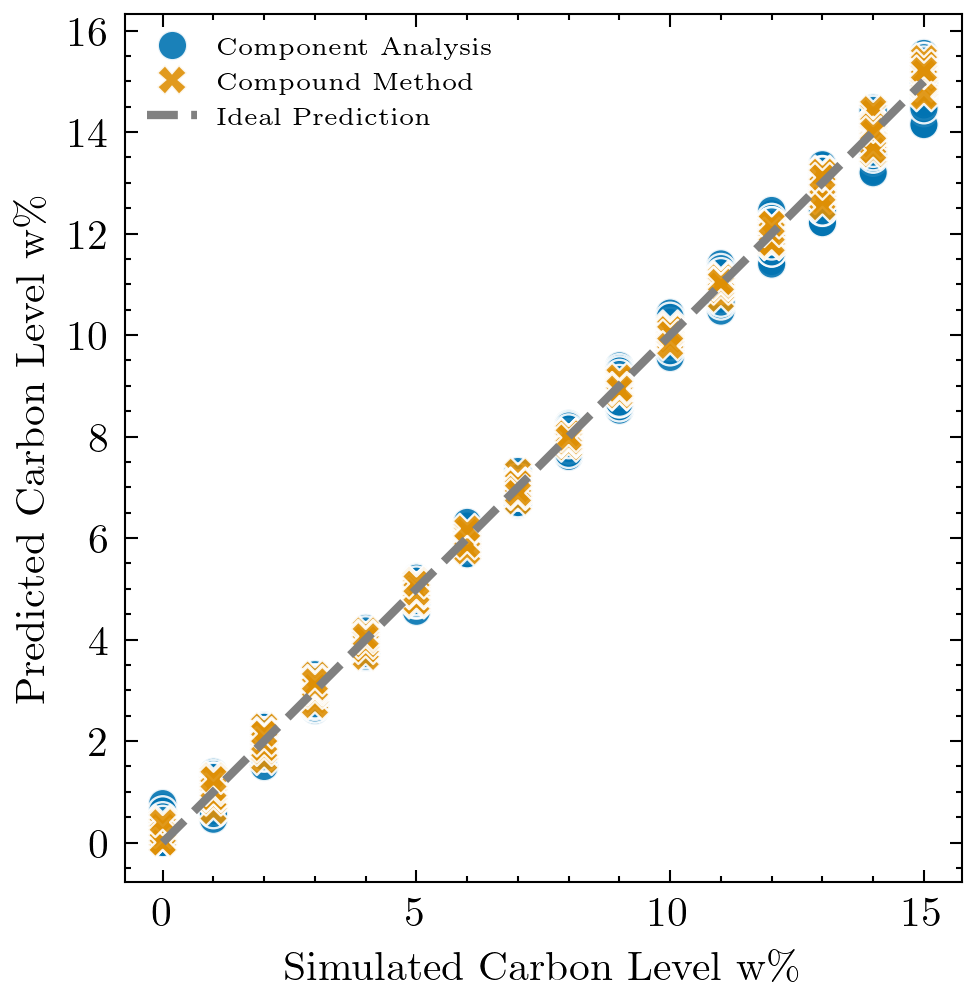

In [22]:
explode_and_graph(best_results.head(3).sort_values(by=['mse'], ascending=False), 'true_carbon', 'predicted_carbon', 
                   'Simulated vs Predicted Carbon Levels',
                   'Simulated Carbon Level w\%', 'Predicted Carbon Level w\%', 
                   'true_vs_predicted_carbon.png', style='method group', hue='method group')

In [23]:
carbon_level_results = analysis_results.copy()
carbon_level_results = carbon_level_results.sort_values(by=['mse'])
# carbon_level_results = carbon_level_results[carbon_level_results['datasets used']=='Material Mixes']

In [24]:
# print(carbon_level_results[['carbon level', 'method', 'mse']].pivot(index='carbon level', columns='method', values='mse').to_markdown())

In [25]:
all_carbon_level_results = analysis_results.copy()
all_carbon_level_results = all_carbon_level_results.sort_values(by=['mse'])
# all_carbon_level_results = all_carbon_level_results[all_carbon_level_results['datasets used']=='Material Mixes']
# all_carbon_level_results = all_carbon_level_results[all_carbon_level_results['carbon level'] == 'All']

In [26]:
dataset_results = analysis_results.copy()
dataset_results = dataset_results.sort_values(by=['mse'])
# dataset_results = dataset_results[dataset_results['carbon level'] == 'Agricultural']
print(dataset_results[['method', 'mse']].to_markdown())

|    | method                                                                 |         mse |
|---:|:-----------------------------------------------------------------------|------------:|
|  8 | Baseline and Peak Fitting with Exponential Falloff + Elemental Maps    | 2.44684e-06 |
|  5 | Component Analysis - Elemental Maps (C Si and O)                       | 4.27503e-06 |
|  4 | Component Analysis - Elemental Maps (C Si and O) with Convex Minimizer | 8.04058e-06 |
|  3 | Baseline and Peak Fitting - Exponential Falloff (C Si and O)           | 9.06223e-06 |
|  1 | Baseline and Peak Fitting - Exponential Falloff (C and Si)             | 1.22068e-05 |
|  2 | Baseline and Peak Fitting - Exponential Falloff (C only)               | 1.62463e-05 |
|  6 | Component Analysis - Elemental Maps (C and Si)                         | 0.000211472 |
|  7 | Component Analysis - Elemental Maps (C only)                           | 0.000751831 |
|  0 | Baseline and Peak Fitting - linear Baseline          

In [27]:
all_results_table(dataset_results, focus=['method'])

| method                                                                 |         mse |
|------------------------------------------------------------------------|-------------|
| Baseline and Peak Fitting with Exponential Falloff + Elemental Maps    | 2.44684e-06 |
| Component Analysis - Elemental Maps (C Si and O)                       | 4.27503e-06 |
| Component Analysis - Elemental Maps (C Si and O) with Convex Minimizer | 8.04058e-06 |
| Baseline and Peak Fitting - Exponential Falloff (C Si and O)           | 9.06223e-06 |
| Baseline and Peak Fitting - Exponential Falloff (C and Si)             | 1.22068e-05 |
| Baseline and Peak Fitting - Exponential Falloff (C only)               | 1.62463e-05 |
| Component Analysis - Elemental Maps (C and Si)                         | 0.000211472 |
| Component Analysis - Elemental Maps (C only)                           | 0.000751831 |
| Baseline and Peak Fitting - linear Baseline                            | 0.00109485  |

LaTeX format:

\begi

# Baseline - Peak Fitting

In [28]:
peak_analysis_results = analysis_results[analysis_results['method group']=='Peak Fitting']
peak_analysis_results = peak_analysis_results.sort_values(by=['mse'])
# peak_analysis_results = peak_analysis_results[peak_analysis_results['datasets used']=='Material Mixes']
# peak_analysis_results = peak_analysis_results[peak_analysis_results['carbon level'] == 'Agricultural']

In [29]:
all_results_table(peak_analysis_results, focus=['method'])

| method                                                       |         mse |
|--------------------------------------------------------------|-------------|
| Baseline and Peak Fitting - Exponential Falloff (C Si and O) | 9.06223e-06 |
| Baseline and Peak Fitting - Exponential Falloff (C and Si)   | 1.22068e-05 |
| Baseline and Peak Fitting - Exponential Falloff (C only)     | 1.62463e-05 |
| Baseline and Peak Fitting - linear Baseline                  | 0.00109485  |

LaTeX format:

\begin{tabular}{lr}
\toprule
method & mse \\
\midrule
Baseline and Peak Fitting - Exponential Falloff (C Si and O) & 9.06e-06 \\
Baseline and Peak Fitting - Exponential Falloff (C and Si) & 1.22e-05 \\
Baseline and Peak Fitting - Exponential Falloff (C only) & 1.62e-05 \\
Baseline and Peak Fitting - linear Baseline & 0.00109 \\
\bottomrule
\end{tabular}



In [30]:
_fit_df = peak_analysis_results.fitting_df.iloc[0].copy()
_fit_df.reset_index(drop=False, inplace=True)
# _fit_df['material1'] = _fit_df.label.apply(lambda x: x.split('M')[1])
_fit_df['material'] = _fit_df.label.apply(lambda x: x.split('_')[0][1:])
# _fit_df['material'] = _fit_df['material1'].where(_fit_df['material1'] != 'C', _fit_df['material2'])

In [31]:
__fit_df = _fit_df.copy()

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


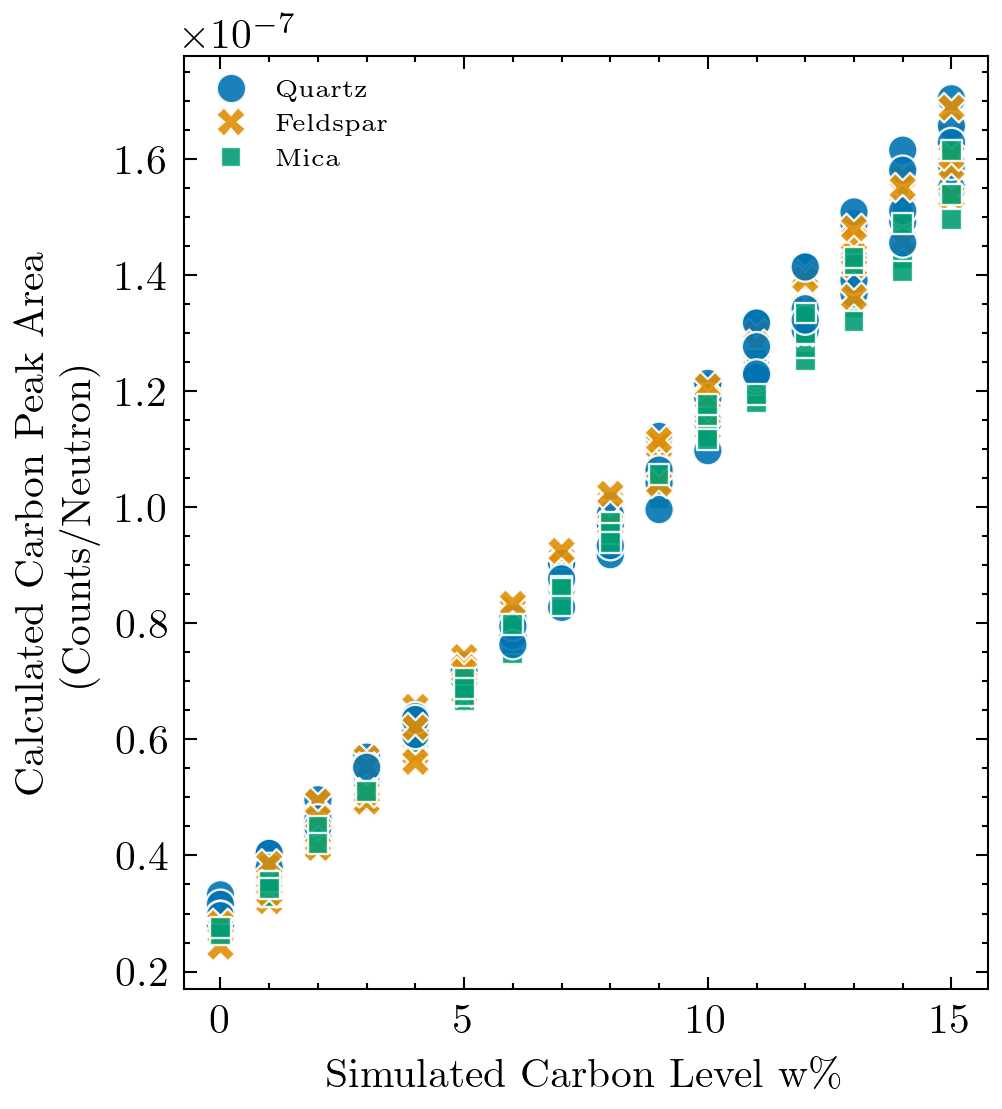

In [32]:
explode_and_graph_other(peak_analysis_results.iloc[0:1], 'true_carbon', 'carbon_peak_areas', 
                   'Simulated vs Peak Areas',
                   'Simulated Carbon Level w\%', 'Calculated Carbon Peak Area\n(Counts/Neutron)',
                   'carbon_level_vs_predicted_pf.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


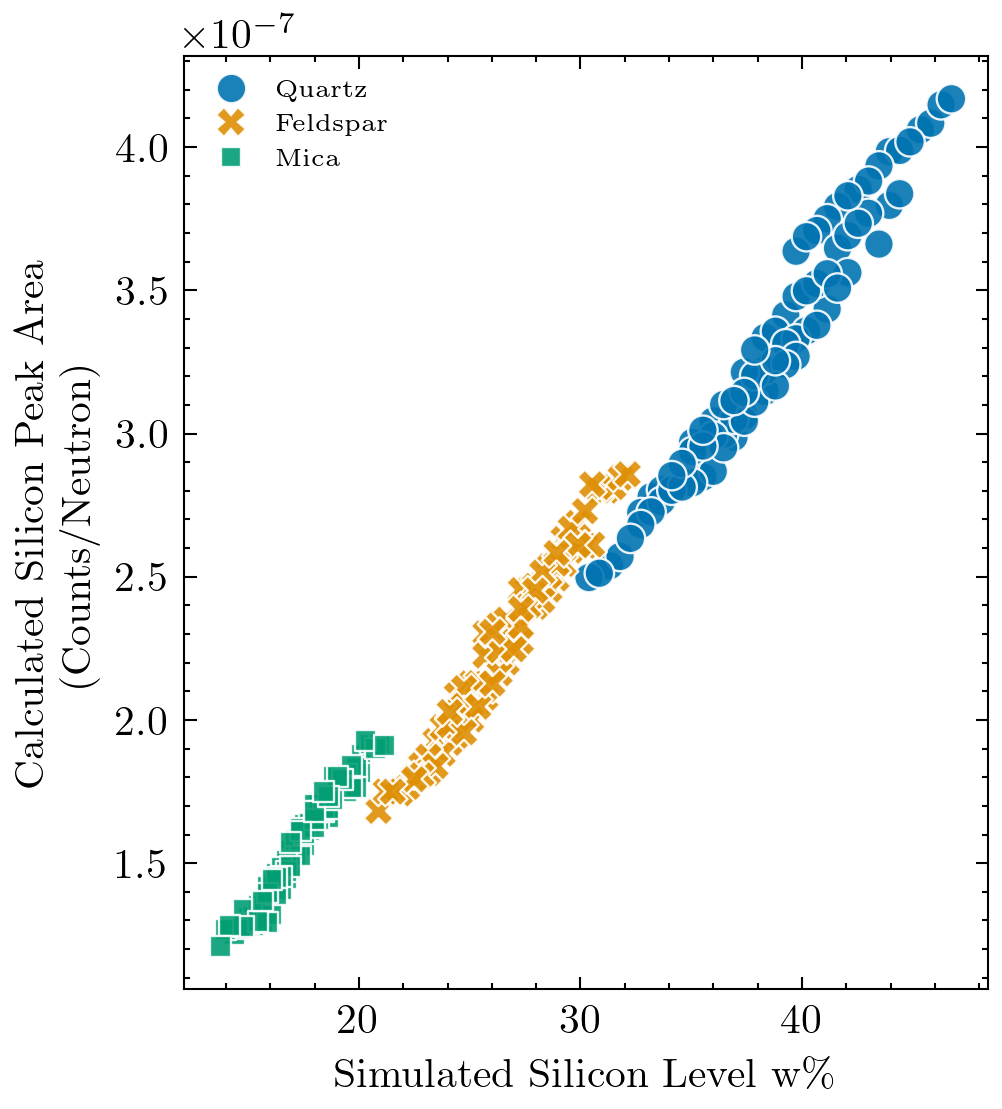

In [67]:
explode_and_graph_other(peak_analysis_results.iloc[0:1], 'true_silicon', 'silicon_peak_areas', 
                   'Simulated vs Peak Areas',
                   'Simulated Silicon Level w\%', 'Calculated Silicon Peak Area\n(Counts/Neutron)',
                   'silicon_level_vs_predicted_pf.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


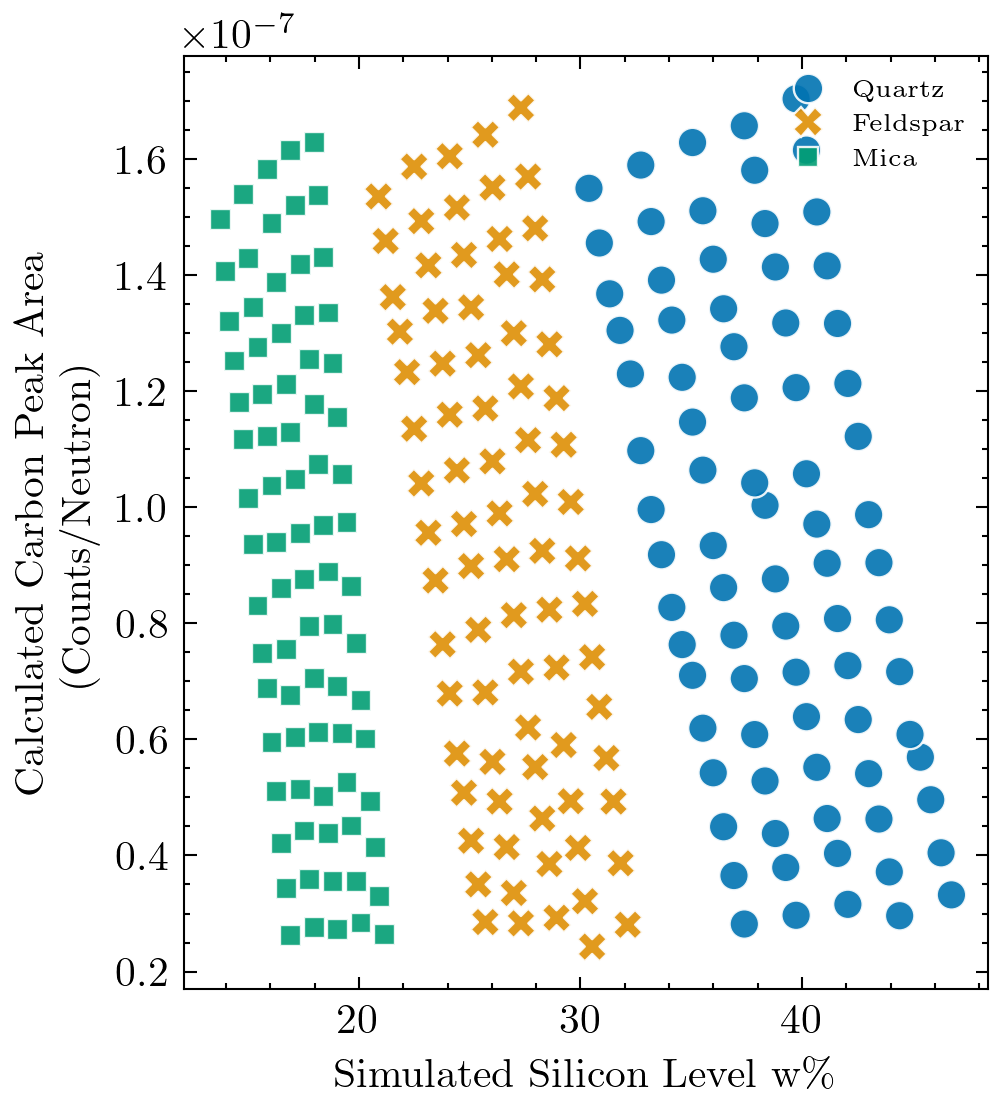

In [82]:
explode_and_graph_other(peak_analysis_results.iloc[0:1], 'true_silicon', 'carbon_peak_areas', 
                   'Simulated vs Peak Areas',
                   'Simulated Silicon Level w\%', 'Calculated Carbon Peak Area\n(Counts/Neutron)',
                   'silicon_level_vs_carbon_pf.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


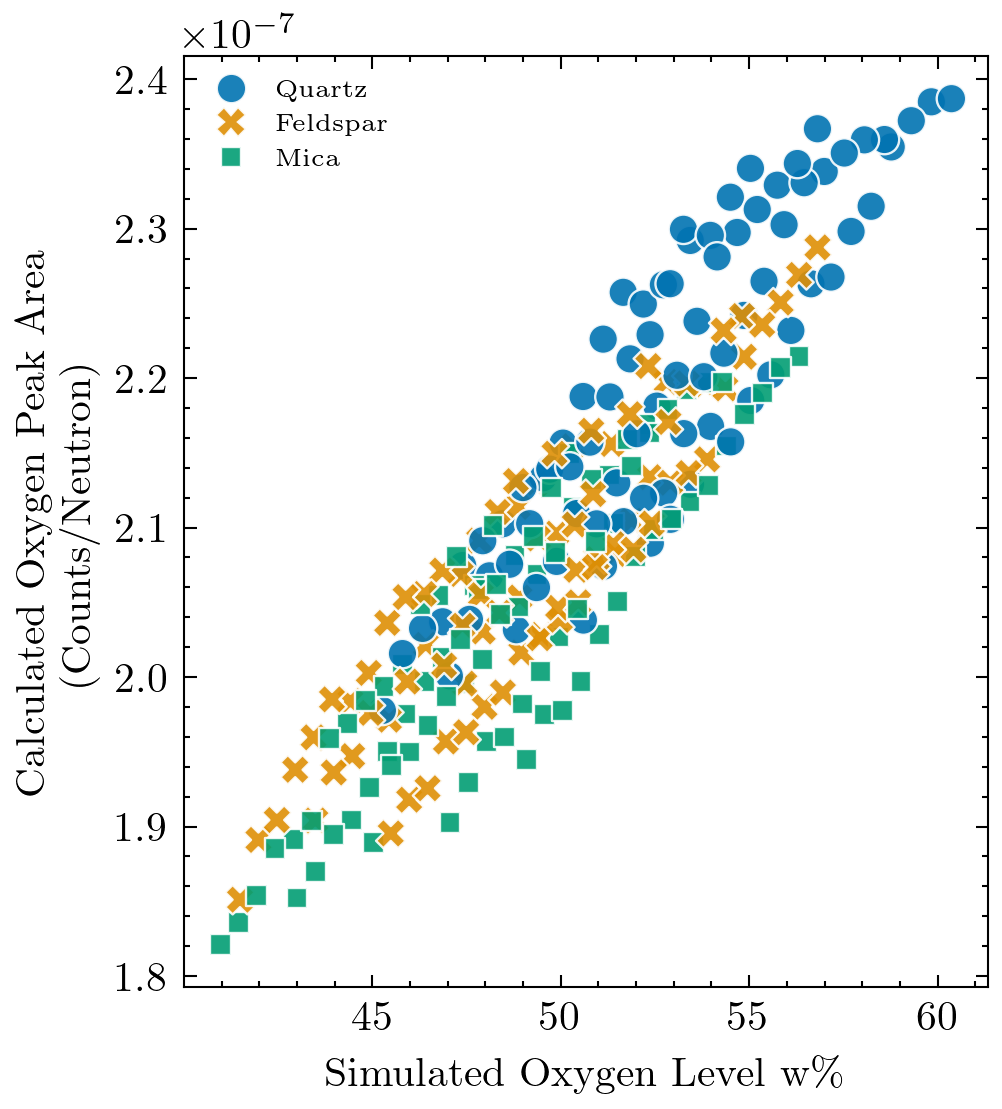

In [68]:
explode_and_graph_other(peak_analysis_results.iloc[0:1], 'true_oxygen', 'oxygen_peak_areas', 
                   'Simulated vs Peak Areas',
                   'Simulated Oxygen Level w\%', 'Calculated Oxygen Peak Area\n(Counts/Neutron)',
                   'oxygen_level_vs_predicted_pf.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

## Final Results

/tmp/ipykernel_1903656/2269838863.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


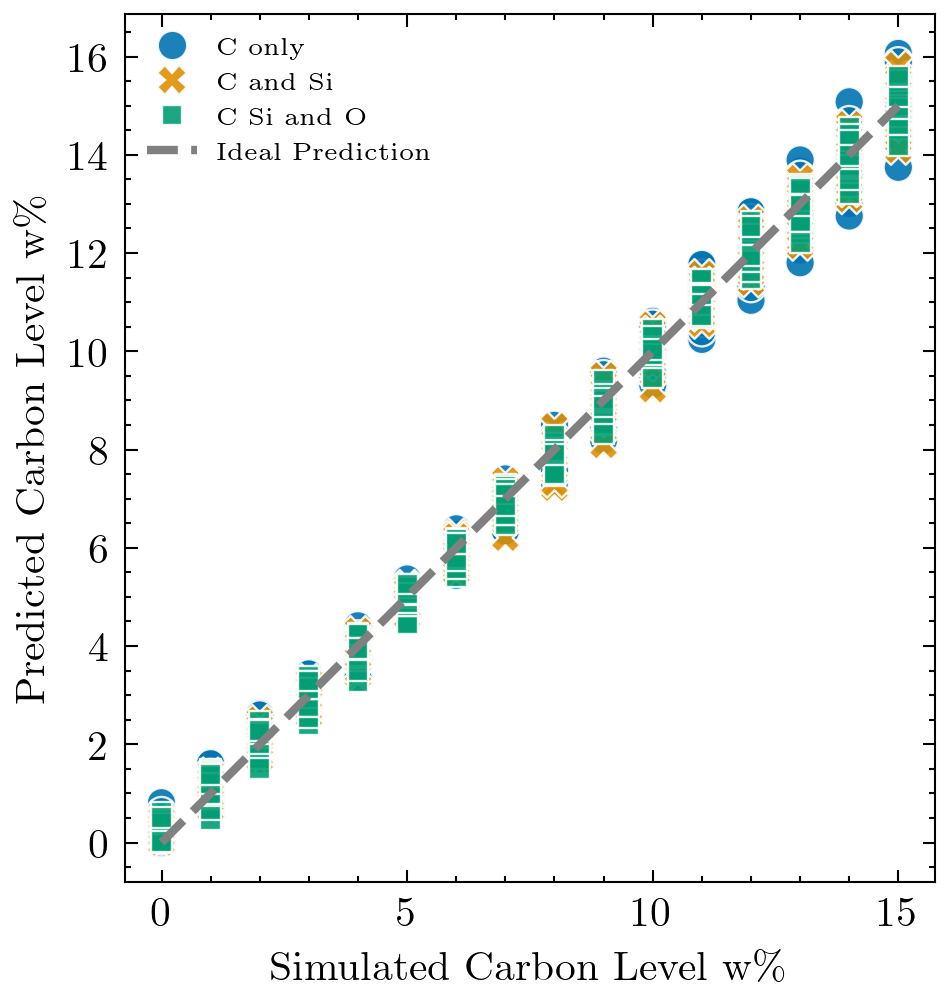

In [35]:
explode_and_graph(peak_analysis_results.sort_values(by='mse', ascending=False), 'true_carbon', 'predicted_carbon', 
                   'Simulated vs Predicted Carbon Level',
                   'Simulated Carbon Level w\%', 'Predicted Carbon Level w\%',
                   'peakfitmultivar.jpg',
                   hue='Variables', style='Variables')

/tmp/ipykernel_1903656/2269838863.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


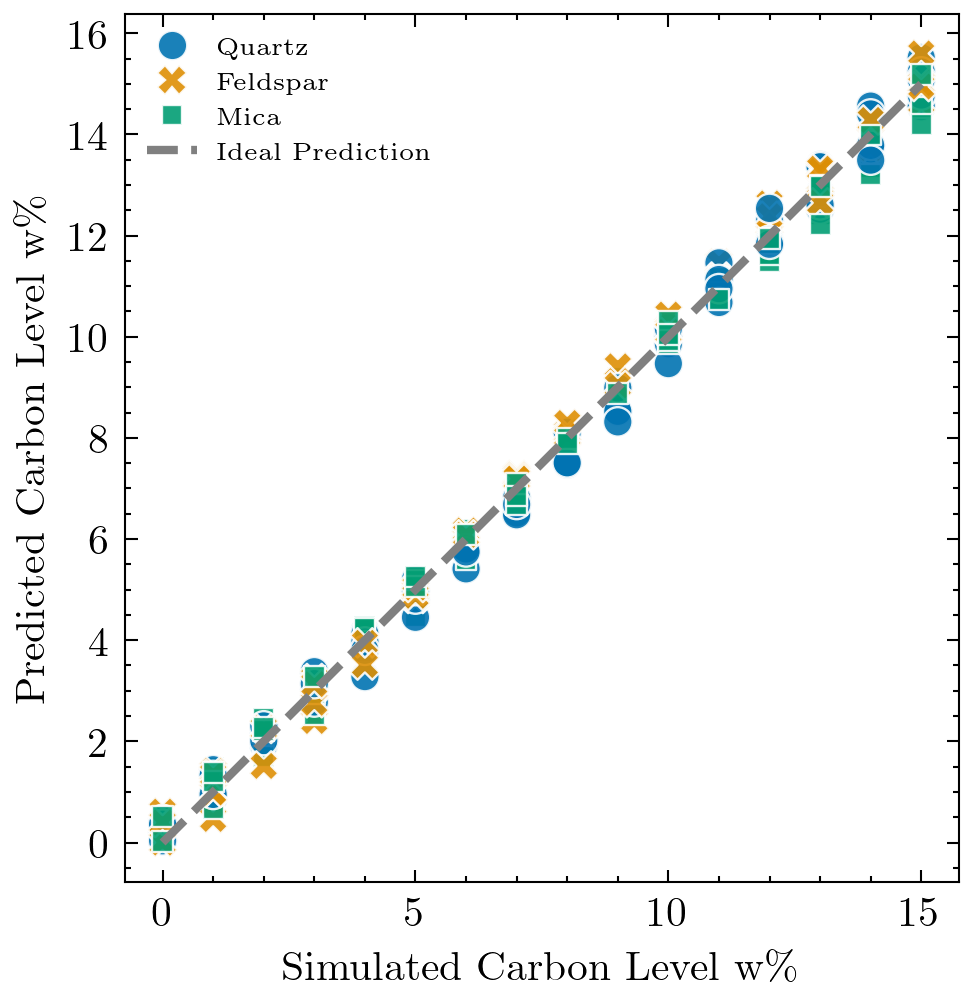

In [36]:
explode_and_graph(peak_analysis_results, 'true_carbon', 'predicted_carbon', 
                   'Simulated vs Predicted Carbon Level',
                   'Simulated Carbon Level w\%', 'Predicted Carbon Level w\%',
                   'carbon_level_vs_predicted.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

## Method

In [37]:
peak_analysis_results.method.unique()

array(['Baseline and Peak Fitting - Exponential Falloff (C Si and O)',
       'Baseline and Peak Fitting - Exponential Falloff (C and Si)',
       'Baseline and Peak Fitting - Exponential Falloff (C only)',
       'Baseline and Peak Fitting - linear Baseline'], dtype=object)

In [38]:
focus_df = peak_analysis_results[peak_analysis_results['method']=='Baseline and Peak Fitting - Exponential Falloff (C Si and O)'].sort_values(by='mse')

_fit_df = focus_df.fitting_df.iloc[0].copy()
_fit_df.reset_index(drop=False, inplace=True)
_fit_df['material1'] = _fit_df.label.apply(lambda x: x.split('_')[1])
_fit_df['material2'] = _fit_df.label.apply(lambda x: x.split('_')[-3])
_fit_df['material'] = _fit_df['material1'].where(_fit_df['material1'] != 'C', _fit_df['material2'])

c_lines_df = focus_df['c_lines_df'].iloc[0]
si_lines_df = focus_df['si_lines_df'].iloc[0]
o_lines_df = focus_df['o_lines_df'].iloc[0]
bins = c_lines_df['bins']
_fit_df['lines'] = [c_lines_df.filter(like=label) for label in _fit_df.label]

_fit_df['true_carbon'] = focus_df['true_carbon'].iloc[0]

In [39]:
# fig, axs = plt.subplots(len(_fit_df.true_carbon.unique()), len(_fit_df.material.unique()), figsize=(len(_fit_df.true_carbon.unique())*3, len(_fit_df.material.unique())*5), sharex=True, sharey=True)
# for j, material in enumerate(_fit_df.material.unique()):
#     for i, carbon_level in enumerate(np.sort(_fit_df.true_carbon.unique())):
#         ax = axs[i, j]
#         _to_plot = _fit_df[(_fit_df.material == material) & (_fit_df.true_carbon == carbon_level)].lines.iloc[0]
#         for col in _to_plot.columns:
#             ax.plot(bins, _to_plot[col], label=col)
#         ax.set_title(f'{material} - {carbon_level}')
#         ax.set_xlabel('Bins')
#         ax.set_ylabel('Counts')
#         ax.grid(True)
#         ax.legend()

# plt.savefig(figure_folder + 'fitting_plot.jpg', bbox_inches='tight')

In [40]:
c_lines_df.columns
# filter to if the column contains 'Feldspar' or '7x7x7'
feldspar_columns = c_lines_df.filter(like='MFeldspar_D1p315_C0p15_H0p0').columns
# seven_by_seven_columns = c_lines_df.filter(like='7x7x7').columns
# both_columns = feldspar_columns.intersection(seven_by_seven_columns)

In [41]:
# # %%
# c_lines_df.columns
# # %%
# # 140 mm wide, 90mm tall
# # plt.rcParams['figure.figsize'] = [5.51, 3.54]
# plt.figure(figsize=[5.51, 3.54])
# # for col in min_carbon_example_fitting_cols:
# # plt.plot(c_lines_df.bins, c_lines_df['7x7x7_C_0600_Feldspar_Fill_003142 true'], label='6\% Carbon in Feldspar', color='tab:green', linewidth=3, alpha=1)
# # plt.plot(c_lines_df.bins, c_lines_df['7x7x7_Feldspar_001021 true'], label='0\% Carbon in Feldspar', color='tab:blue', linewidth=3, alpha=1)
# plt.scatter(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p15_H0p0 true'], label='15\% Carbon in Feldspar', color='tab:green', linewidth=1, alpha=1)
# plt.scatter(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p0_H0p0 true'], label='0\% Carbon in Feldspar', color='tab:blue', linewidth=1, alpha=1)

# plt.plot(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p0_H0p0 peak'], label='Peak', color='red', linestyle='--', alpha=1, linewidth=1)
# plt.plot(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p0_H0p0 baseline'], label='Baseline', color='black', linestyle='--', alpha=1)
# plt.plot(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p15_H0p0 peak'], color='red', linestyle='--', alpha=1, linewidth=1)
# plt.plot(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p15_H0p0 baseline'], color='black', linestyle='--', alpha=1)
# plt.legend(
#     fontsize=8
#     )
# plt.xlabel('Energy (MeV)')
# plt.ylabel('Counts/Neutron')
# plt.title('Peak Fitting for Feldspar with Natural Carbon Levels\nExponential Falloff Baseline')
# # plt.savefig(figure_folder+'peak_fitting_feldspar.png', bbox_inches='tight')
# plt.show()

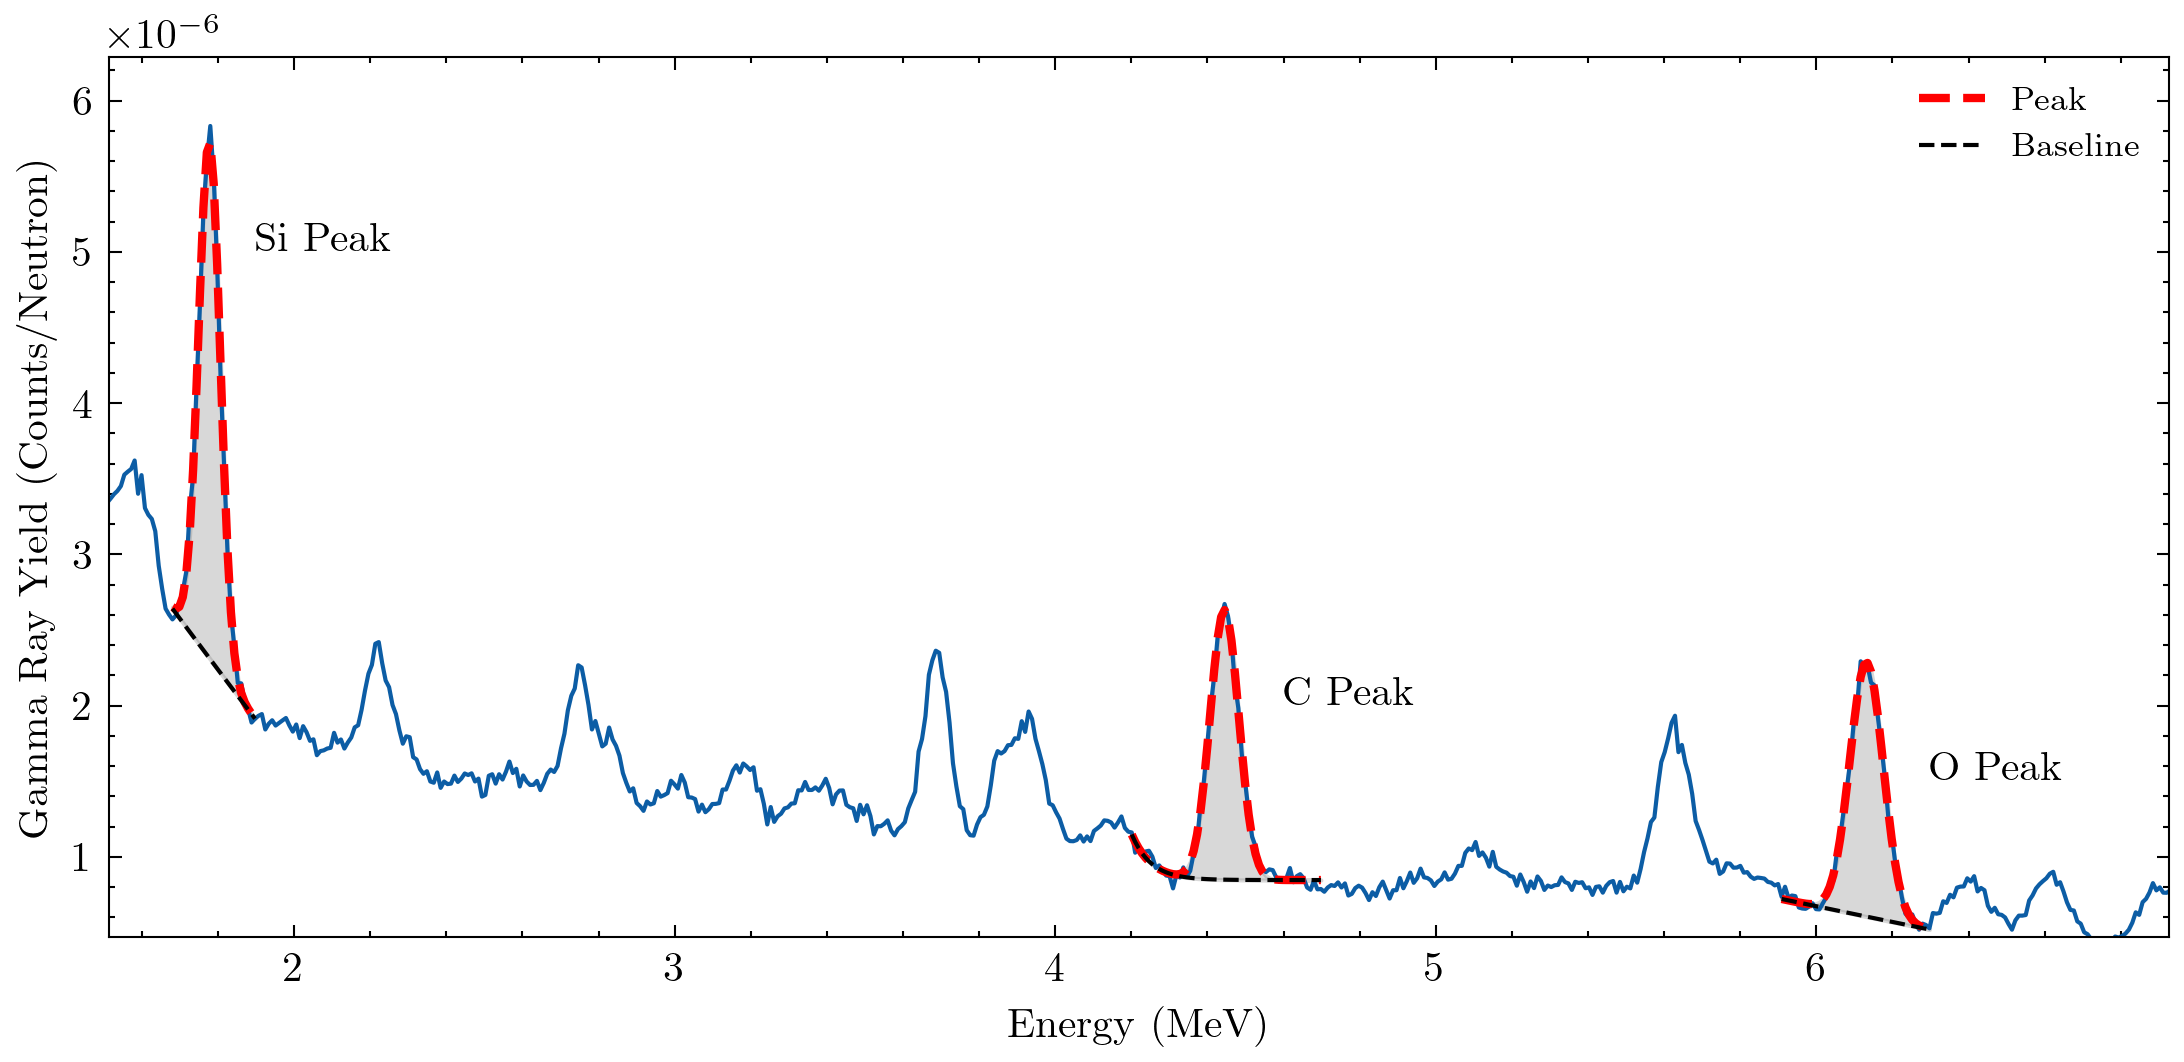

In [42]:
fig, (ax2) = plt.subplots(1, 1, figsize=[double_col_width, double_col_width*.5], sharex=True, sharey=True)

# # 0% Carbon subplot
# ax1.scatter(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p0_H0p0 true'], label='0\% Carbon in Feldspar', color='tab:blue', linewidth=1, alpha=1)
# ax1.plot(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p0_H0p0 peak'], label='Peak', color='red', linestyle='--', alpha=1, linewidth=1)
# ax1.plot(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p0_H0p0 baseline'], label='Baseline', color='black', linestyle='--', alpha=1)
# ax1.fill_between(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p0_H0p0 baseline'], c_lines_df['MFeldspar_D1p315_C0p0_H0p0 peak'], color='gray', alpha=0.3)
# ax1.set_xlabel('Energy (MeV)')
# ax1.set_ylabel('Counts/Neutron')
# ax1.set_title('Peak Fitting for Feldspar (0\% Carbon)\nExponential Falloff Baseline')
# ax1.legend(fontsize=8)

# 6% Carbon subplot
_target = 'MFeldspar_D1p315_C0p15_H0p0'
ax2.plot(detector_readings.index, detector_readings[_target])
# ax2.scatter(c_lines_df.bins, c_lines_df['MFeldspar_D1p315_C0p15_H0p0 true'], label='15\% Carbon in Feldspar', color='tab:green', linewidth=1, alpha=1)
ax2.plot(c_lines_df.bins, c_lines_df[_target + ' peak'], label='Peak', color='red', linestyle='--', alpha=1, linewidth=2)
ax2.plot(c_lines_df.bins, c_lines_df[_target + ' baseline'], label='Baseline', color='black', linestyle='--', alpha=1)
ax2.fill_between(c_lines_df.bins, c_lines_df[_target + ' baseline'], c_lines_df[_target + ' peak'], color='gray', alpha=0.3)
ax2.plot(si_lines_df.bins, si_lines_df[_target + ' peak'], color='red', linestyle='--', alpha=1, linewidth=2)
ax2.plot(si_lines_df.bins, si_lines_df[_target + ' baseline'], color='black', linestyle='--', alpha=1)
ax2.fill_between(si_lines_df.bins, si_lines_df[_target + ' baseline'], si_lines_df[_target + ' peak'], color='gray', alpha=0.3)
ax2.plot(o_lines_df.bins, o_lines_df[_target + ' peak'], color='red', linestyle='--', alpha=1, linewidth=2)
ax2.plot(o_lines_df.bins, o_lines_df[_target + ' baseline'], color='black', linestyle='--', alpha=1)
ax2.fill_between(o_lines_df.bins, o_lines_df[_target + ' baseline'], o_lines_df[_target + ' peak'], color='gray', alpha=0.3)
max_ylimit = max(
    c_lines_df[_target + ' peak'].max(),
    si_lines_df[_target + ' peak'].max(),
    o_lines_df[_target + ' peak'].max()
)
min_ylimit = min(
    c_lines_df[_target + ' baseline'].min(),
    si_lines_df[_target + ' baseline'].min(),
    o_lines_df[_target + ' baseline'].min()
)

max_xlimit = max(
    c_lines_df.bins.max(),
    si_lines_df.bins.max(),
    o_lines_df.bins.max()
)
min_xlimit = min(
    c_lines_df.bins.min(),
    si_lines_df.bins.min(),
    o_lines_df.bins.min()
)
ax2.set_xlim(min_xlimit*0.9, max_xlimit*1.1)
# ax2.set_xlim(1.6, 2)
ax2.set_ylim(min_ylimit*0.9, max_ylimit*1.1)



ax2.set_xlabel('Energy (MeV)')
ax2.set_ylabel('Gamma Ray Yield (Counts/Neutron)')
# ax2.set_title('Peak Fitting for Feldspar (15\% Carbon)\nExponential Falloff Baseline')
ax2.legend(fontsize=8)
# ax2.set_yscale('log')
plt.text(1.9, 5e-6, "Si Peak")
plt.text(4.6, 2e-6, "C Peak")
plt.text(6.3, 1.5e-6, "O Peak")
plt.tight_layout()
plt.savefig(figure_folder+'peak_fitting_feldspar_subplots.png', bbox_inches='tight')
plt.show()


# Component Analysis

In [43]:
analysis_results['method group'].unique()

array(['Peak Fitting', 'Component Analysis', 'Compound Method'],
      dtype=object)

In [44]:
component_analysis_results = analysis_results[analysis_results['method group']=='Component Analysis']
component_analysis_results = component_analysis_results.sort_values(by=['mse'])
# component_analysis_results = component_analysis_results[component_analysis_results['datasets used']=='Material Mixes']
# component_analysis_results = component_analysis_results[component_analysis_results['carbon level'] == 'Agricultural']

In [45]:
all_results_table(component_analysis_results, focus=['Variables'])

| Variables   |         mse |
|-------------|-------------|
| C Si and O  | 4.27503e-06 |
| C Si and O  | 8.04058e-06 |
| C and Si    | 0.000211472 |
| C only      | 0.000751831 |

LaTeX format:

\begin{tabular}{lr}
\toprule
Variables & mse \\
\midrule
C Si and O & 4.28e-06 \\
C Si and O & 8.04e-06 \\
C and Si & 0.000211 \\
C only & 0.000752 \\
\bottomrule
\end{tabular}



In [46]:
component_analysis_results.iloc[0:1]

,mse,fitting_df,carbon_fitting_df,si_fitting_df,c_lines_df,si_lines_df,carbon_peak_areas,silicon_peak_areas,oxygen_peak_areas,training_carbon_peak_areas,...,Variables,predicted_df,combined_df,train_cols,carbon_portions,silicon_portions,oxygen_portions,training_carbon_portions,test_carbon_portions,id
5,0.000004,C ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,C Si and O,Carbon Portion M...,MQuartz_D1p315_C0p04_H0p2 MQuartz_D...,"[C, H, O, Si, Na, Al, K]","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285732923, 0.14285714285904133, 0.1...","[0.14285714285758416, 0.1428571428584485, 0.14...","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285750653, 0.14285714285727377, 0.1...",5


In [ ]:
___ = component_analysis_results.iloc[1:2]
___['carbon_portions'] = ___['carbon_portions'].apply(lambda row: row*100)

/tmp/ipykernel_1903656/3001306629.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ___['carbon_portions'] = ___['carbon_portions'].apply(lambda row: row*100)


In [93]:
___['method']

4    Component Analysis - Elemental Maps (C Si and ...
Name: method, dtype: object

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


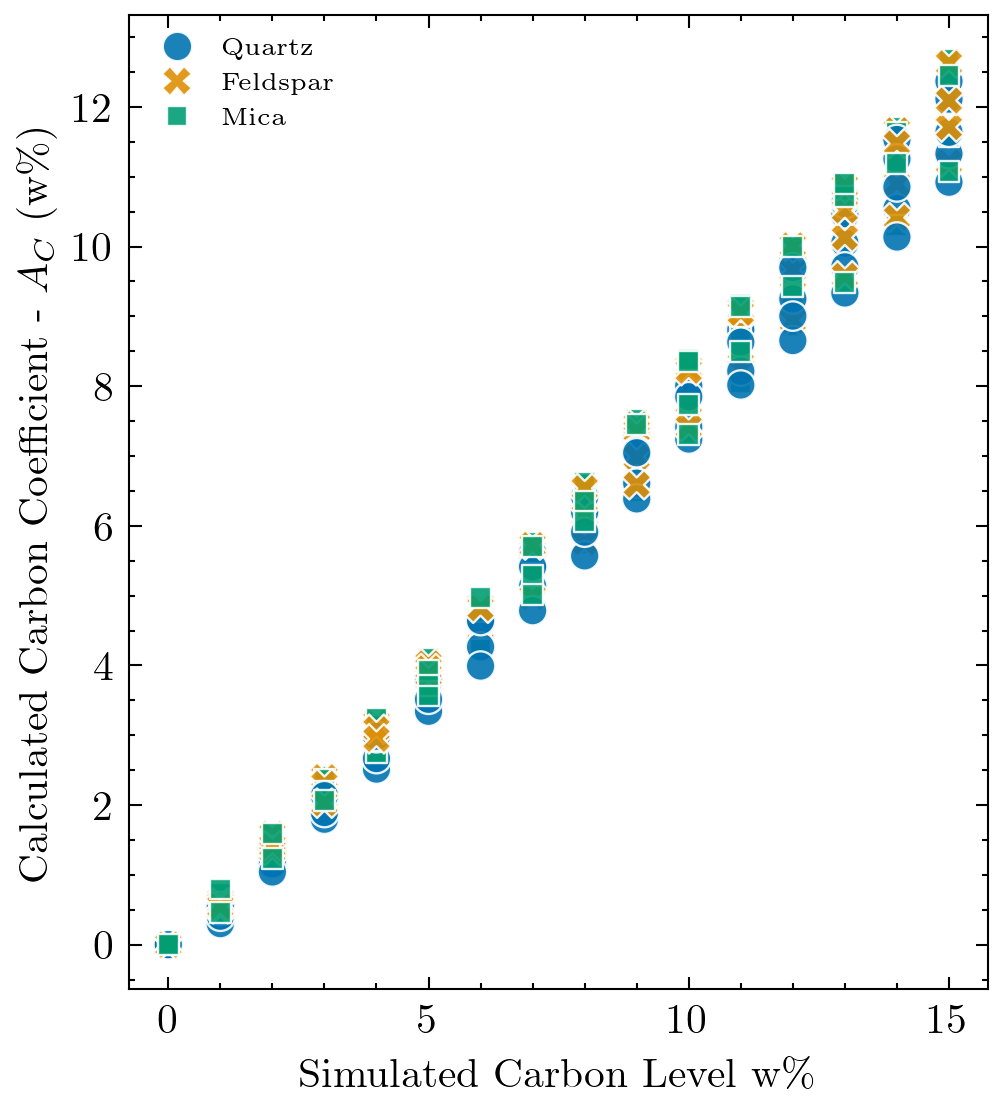

In [94]:
explode_and_graph_other(___, 'true_carbon', 'carbon_portions', 
                   'Simulated Carbon Level vs Determined Carbon Coefficient',
                   'Simulated Carbon Level w\%', 'Calculated Carbon Coefficient - $A_{C}$ (w\%)',
                   'carbon_level_vs_predicted_ef.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


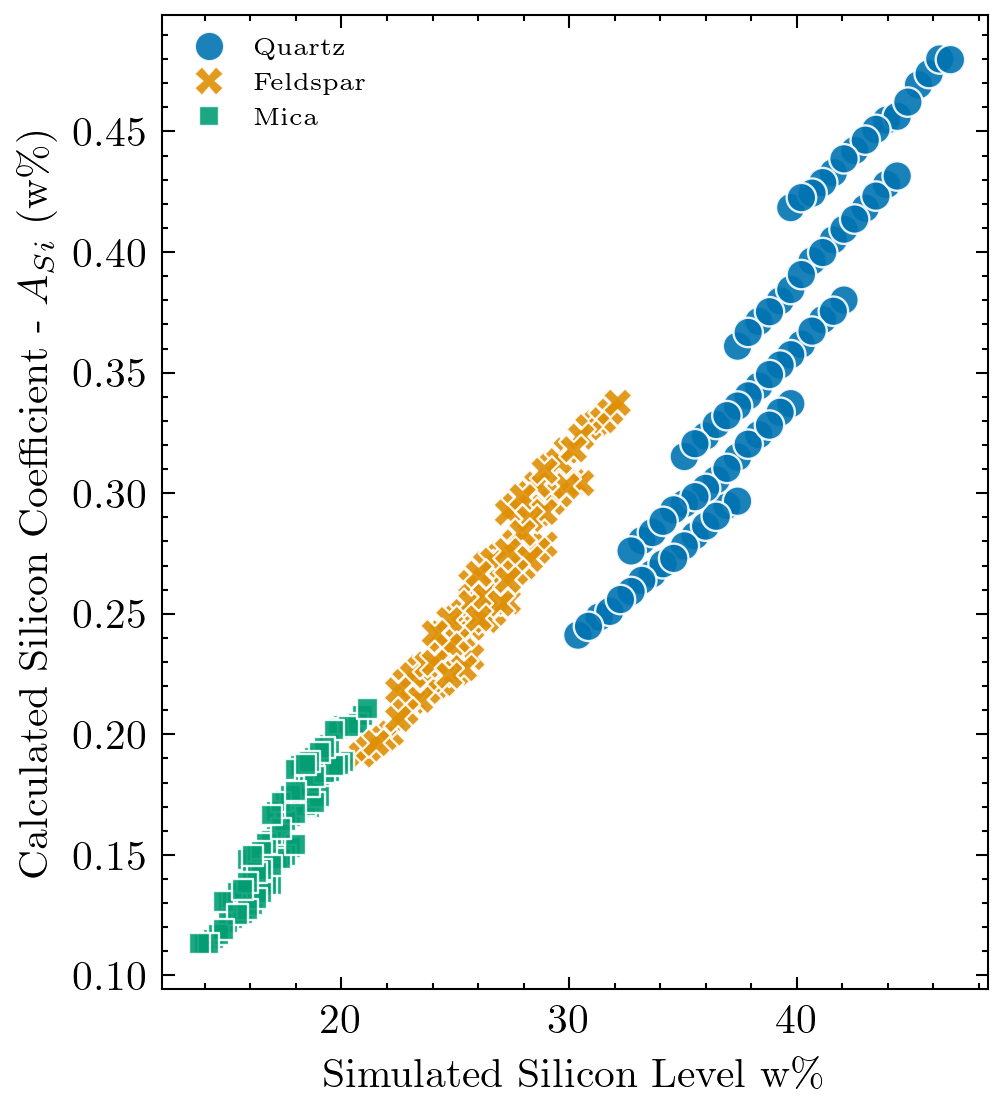

In [95]:
explode_and_graph_other(___, 'true_silicon', 'silicon_portions', 
                   'Simulated Silicon Level vs Determined Silicon Coefficient',
                   'Simulated Silicon Level w\%', 'Calculated Silicon Coefficient - $A_{Si}$ (w\%)',
                   'silicon_level_vs_predicted_ef.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


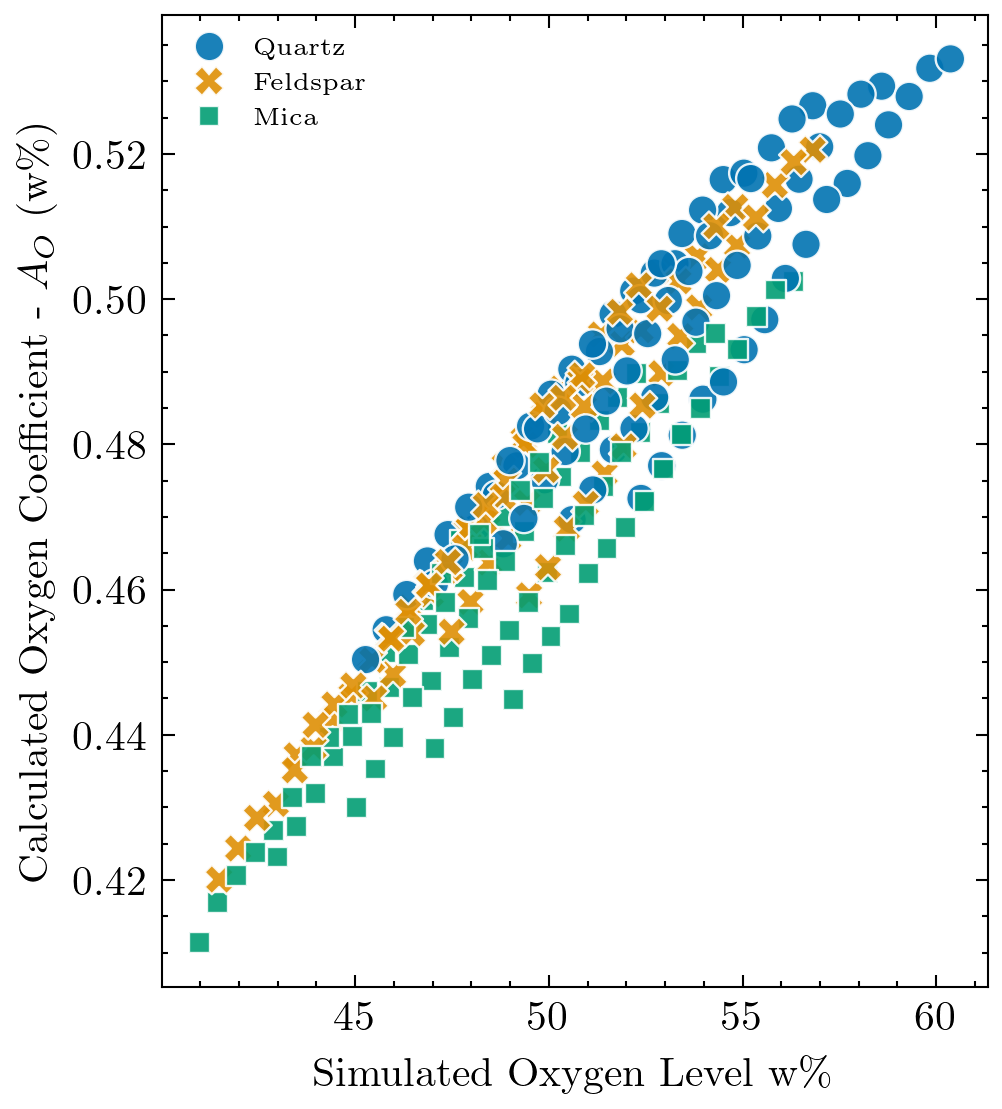

In [96]:
explode_and_graph_other(___, 'true_oxygen', 'oxygen_portions',
                   'Simulated Oxygen Level vs Determined Oxygen Coefficient',
                   'Simulated Oxygen Level w\%', 'Calculated Oxygen Coefficient - $A_{O}$ (w\%)',
                   'oxygen_level_vs_predicted_ef.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


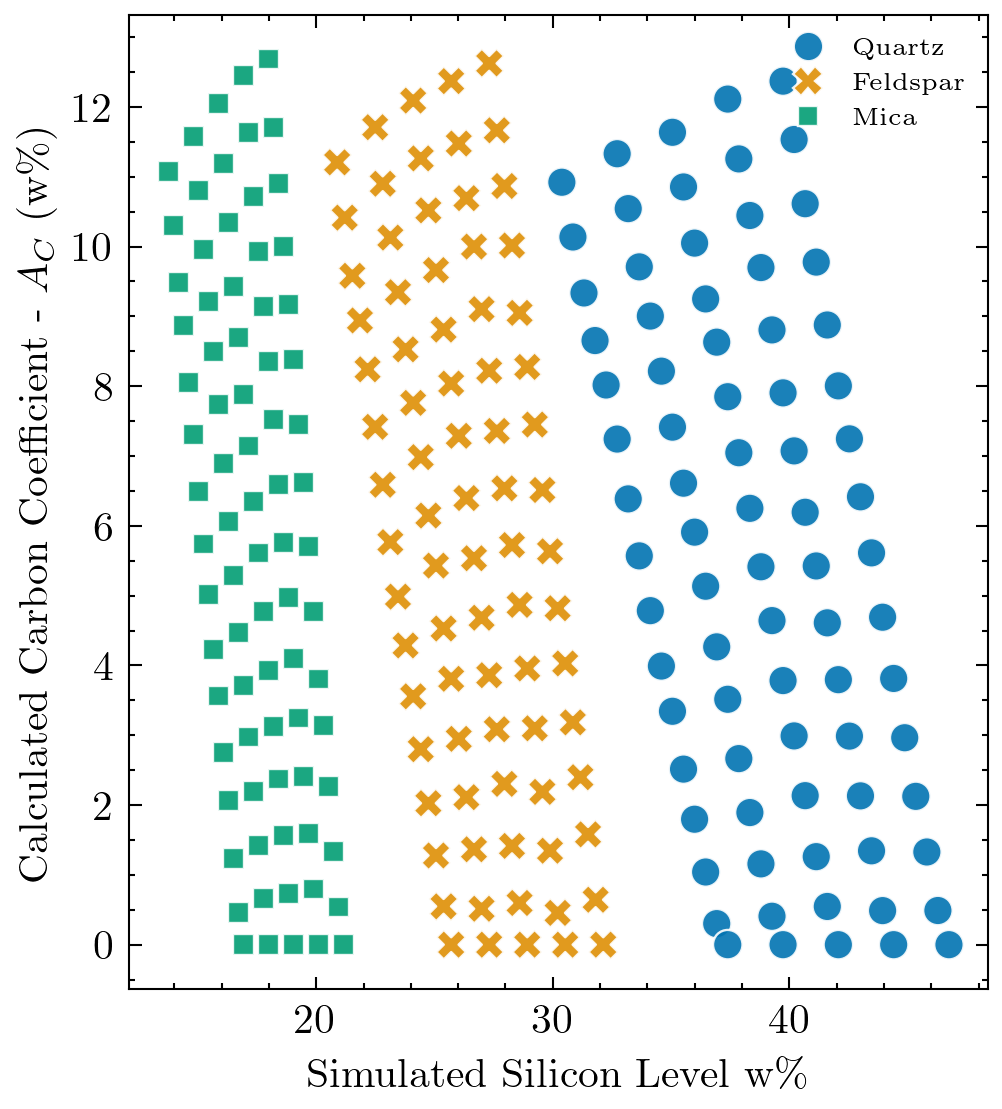

In [97]:
explode_and_graph_other(___, 'true_silicon', 'carbon_portions', 
                   'Simulated Silicon Level vs Determined Carbon Coefficient',
                   'Simulated Silicon Level w\%', 'Calculated Carbon Coefficient - $A_{C}$ (w\%)',
                   'silicon_level_vs_carbon_ef.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

/tmp/ipykernel_1903656/1579686077.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


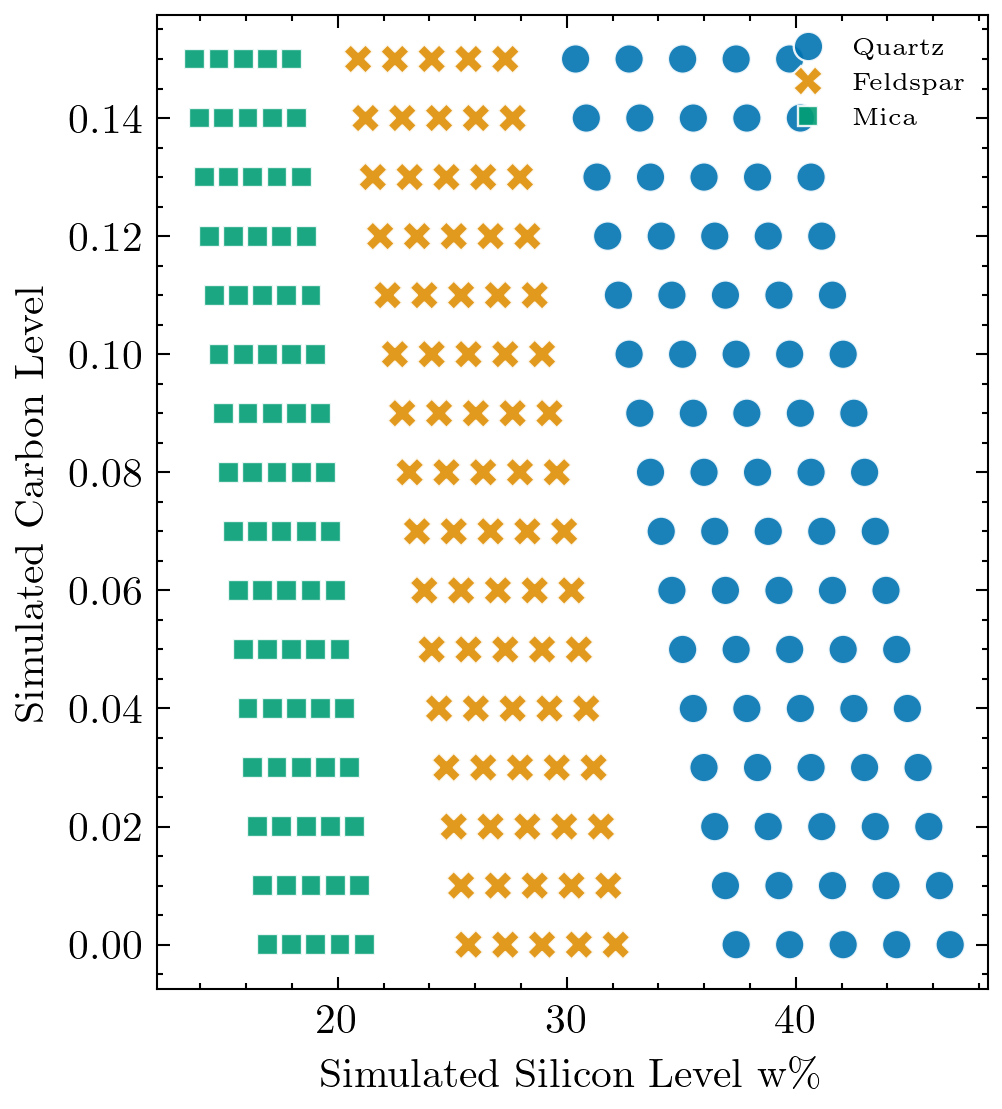

In [124]:
explode_and_graph_other(___, 'true_silicon', 'true_carbon', 
                   'Simulated Silicon Level vs Simulated Carbon Level',
                   'Simulated Silicon Level w\%', 'Simulated Carbon Level',
                   'silicon_level_vs_carbon_ef.jpg',
                   hue=__fit_df['material'],style=__fit_df['material'])

In [125]:

# explode_and_graph_other(component_analysis_results.iloc[0:2], 'true_carbon', 'carbon_portions', 
#                    'Simulated Carbon Level vs Determined Carbon Coefficient',
#                    'Simulated Carbon Level w\%', 'Calculated Carbon Coefficient - $A_{C}$ (w\%)',
#                    'carbon_level_vs_predicted_ef.jpg',
#                    hue='method', style='method')

In [87]:
component_analysis_results.sort_values(by='mse', ascending=False)

,mse,fitting_df,carbon_fitting_df,si_fitting_df,c_lines_df,si_lines_df,carbon_peak_areas,silicon_peak_areas,oxygen_peak_areas,training_carbon_peak_areas,...,Variables,predicted_df,combined_df,train_cols,carbon_portions,silicon_portions,oxygen_portions,training_carbon_portions,test_carbon_portions,id
7,0.000752,C ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,C only,Carbon Portion M...,MQuartz_D1p315_C0p04_H0p2 MQuartz_D...,"[C, H, O, Si, Na, Al, K]","[0.1428571428569292, 0.14285714285660217, 0.14...","[0.1428571428573573, 0.14285714285812212, 0.14...","[0.14285714285761222, 0.1428571428575293, 0.14...","[0.1428571428569292, 0.14285714285660217, 0.14...","[0.14285714285657, 0.1428571428566957, 0.14285...",7
6,0.000211,C ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,C and Si,Carbon Portion M...,MQuartz_D1p315_C0p04_H0p2 MQuartz_D...,"[C, H, O, Si, Na, Al, K]","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285732923, 0.14285714285904133, 0.1...","[0.14285714285758416, 0.1428571428584485, 0.14...","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285750653, 0.14285714285727377, 0.1...",6
4,0.000008,C ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,C Si and O,Carbon Portion M...,MQuartz_D1p315_C0p04_H0p2 MQuartz_D...,"[C, H, O, Si, Na, Al, K]","[0.025148292830120992, 0.0048792993354533215, ...","[0.28240094498231033, 0.42801618126509516, 0.2...","[0.5197508899939773, 0.5164619554354812, 0.505...","[0.025148292830120992, 0.0048792993354533215, ...","[0.0, 0.00547180905374327, 0.00407207599065855...",4
5,0.000004,C ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,C Si and O,Carbon Portion M...,MQuartz_D1p315_C0p04_H0p2 MQuartz_D...,"[C, H, O, Si, Na, Al, K]","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285732923, 0.14285714285904133, 0.1...","[0.14285714285758416, 0.1428571428584485, 0.14...","[0.14285714285690113, 0.14285714285752138, 0.1...","[0.14285714285750653, 0.14285714285727377, 0.1...",5


/tmp/ipykernel_1903656/2269838863.py:9: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


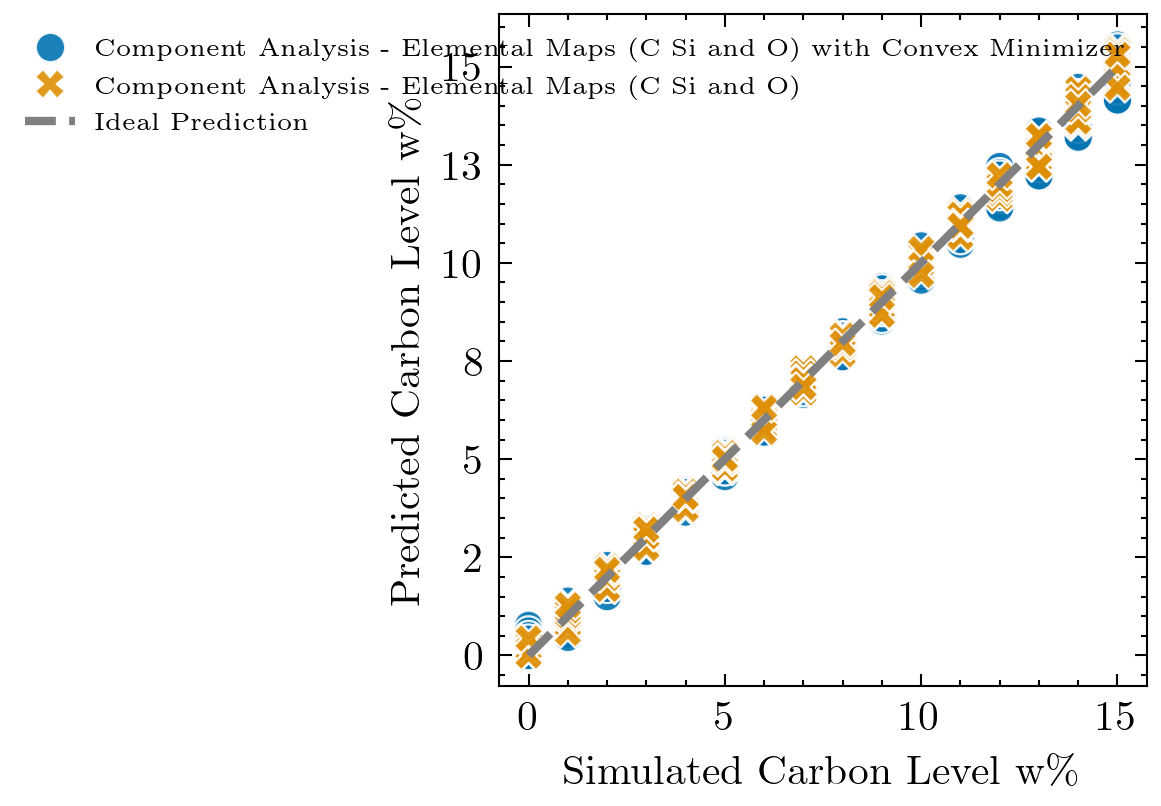

In [89]:
explode_and_graph(component_analysis_results.sort_values(by='mse', ascending=False).tail(2), 'true_carbon', 'predicted_carbon', 
                   'Multivariate Calibration Improves Results',
                   'Simulated Carbon Level w\%', 'Predicted Carbon Level w\%',
                   'edgemembermultivar.jpg',
                   hue='method', style='method')

## final

In [ ]:
peak_analysis_results

/tmp/ipykernel_1903656/2269838863.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


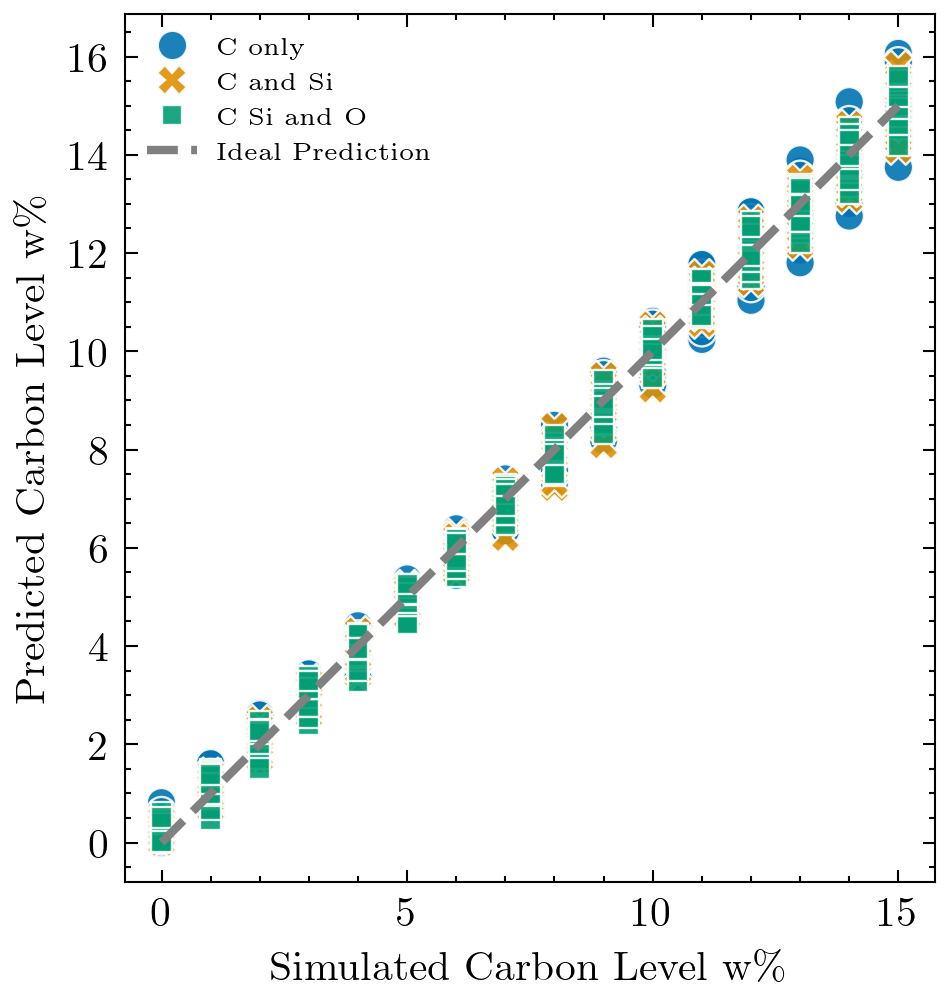

In [127]:
explode_and_graph(peak_analysis_results.sort_values(by='mse', ascending=False), 'true_carbon', 'predicted_carbon', 
                   'Multivariate Calibration Improves Results',
                   'Simulated Carbon Level w\%', 'Predicted Carbon Level w\%',
                   'peakmultivar.jpg',
                   hue='Variables', style='Variables')

/tmp/ipykernel_1903656/2269838863.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=explode_vals_df, x=x_col, y=y_col, alpha=.9, hue=hue, style=style, s=50, palette=palette)


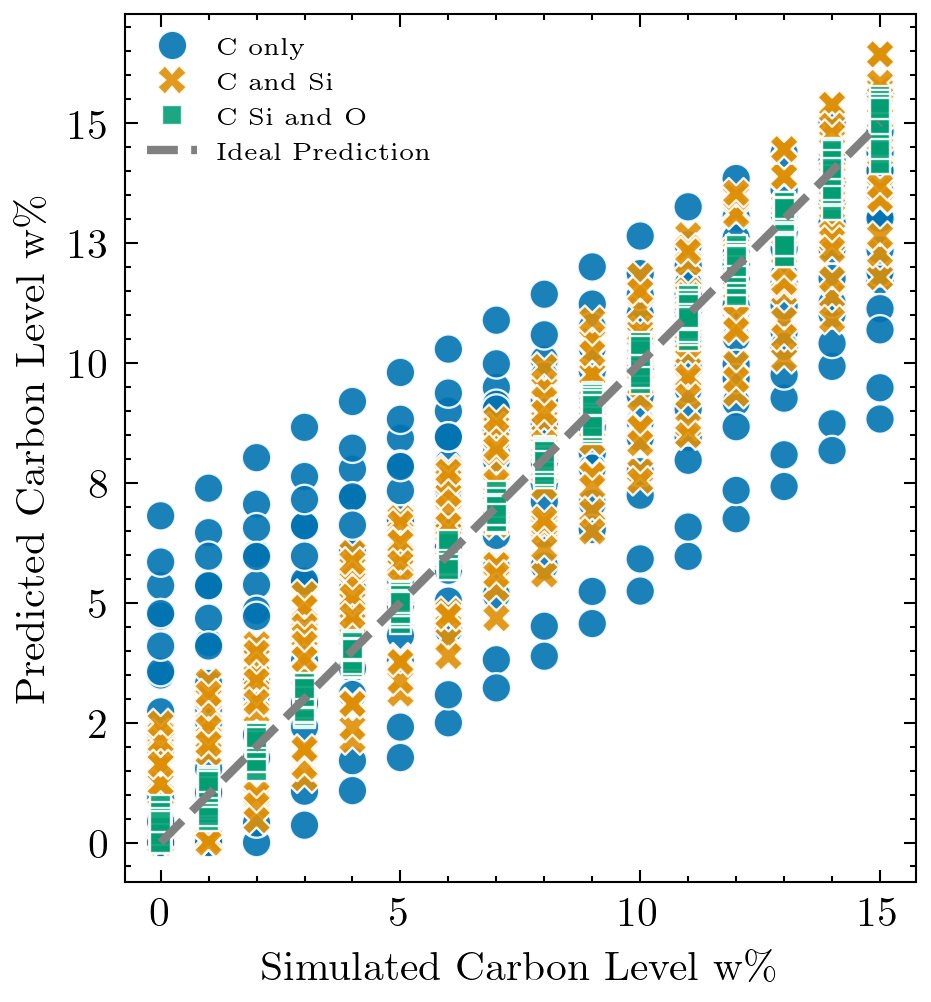

In [49]:
explode_and_graph(component_analysis_results.sort_values(by='mse', ascending=False), 'true_carbon', 'predicted_carbon', 
                   'Multivariate Calibration Improves Results',
                   'Simulated Carbon Level w\%', 'Predicted Carbon Level w\%',
                   'edgemembermultivar.jpg',
                   hue='Variables', style='Variables')

In [50]:
# explode_and_graph(component_analysis_results, 'true_carbon', 'predicted_carbon', 
#                    'Simulated vs Predicted Carbon Level',
#                    'Simulated Carbon Level w\%', 'Predicted Carbon Level w\%',
#                    'carbon_level_vs_predicted_component_fitting.jpg',
#                    hue=__fit_df['material'],style=__fit_df['material'])

## method

In [98]:
analysis_results.method.unique()

array(['Baseline and Peak Fitting - linear Baseline',
       'Baseline and Peak Fitting - Exponential Falloff (C and Si)',
       'Baseline and Peak Fitting - Exponential Falloff (C only)',
       'Baseline and Peak Fitting - Exponential Falloff (C Si and O)',
       'Component Analysis - Elemental Maps (C Si and O) with Convex Minimizer',
       'Component Analysis - Elemental Maps (C Si and O)',
       'Component Analysis - Elemental Maps (C and Si)',
       'Component Analysis - Elemental Maps (C only)',
       'Baseline and Peak Fitting with Exponential Falloff + Elemental Maps'],
      dtype=object)

In [99]:
_df = analysis_results
_df = _df[_df['method']=='Component Analysis - Elemental Maps (C Si and O) with Convex Minimizer']
test = _df.iloc[0]

In [100]:
target=test['fitting_df'].index[5]
target

'MMica_D1p315_C0p02_H0p1'

In [101]:
w_df = test['fitting_df'].loc[target]
weights = w_df.values

In [102]:
unweighted_spectrums = _df['combined_df'].iloc[0][test['fitting_df'].loc[target].index].values.T

In [103]:
weighted_spectrums = np.multiply(weights, unweighted_spectrums.T).T

In [104]:
summed_spectrum = np.matmul(weights, unweighted_spectrums)

In [105]:
# find index of 4.44
index_4_44 = np.where(bins < 4.44)[0][-1]
order = weighted_spectrums[:, index_4_44].argsort()[::-1]
order = np.argsort(weights)
elem_names = test['fitting_df'].loc[target].index

In [106]:
bins = _df['combined_df'].iloc[0].index

In [107]:
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
hatches = ['/', '\\', '|', '-', 'x', '*', 'O', '.']

In [108]:
# tabulate elem_names and weights with full significant figures
print(tabulate(
    zip(elem_names, weights-np.round(min(weights), 13)),
    headers=['Element', f'Weight - {np.round(min(weights), 12)}'],
    tablefmt='github',
    floatfmt=".4g"
))

| Element   |   Weight - 0.0 |
|-----------|----------------|
| C         |        0.01563 |
| H         |        0.1573  |
| O         |        0.4833  |
| Si        |        0.1694  |
| Na        |        0       |
| Al        |        0.1743  |
| K         |        0       |


In [109]:
from tabulate import tabulate

print(f"Taget: {target}")
print(tabulate(
    zip(elem_names, weights, sims.loc[target]['element_mat']),
    headers=['Element', f'Pred W\%', 'True W\%'],
    tablefmt='github',
    floatfmt=".4g"
))

# Print the table in LaTeX format

print("\nLaTeX format:\n")
print(tabulate(
    zip(elem_names, weights, sims.loc[target]['element_mat']),
    headers=['Element', 'Coefficient', 'True Weight'],
    tablefmt='latex',
    floatfmt=".4g"
))

Taget: MMica_D1p315_C0p02_H0p1
| Element   |   Pred W\% |   True W\% |
|-----------|------------|------------|
| C         |    0.01563 |    0.02    |
| H         |    0.1573  |    0.01564 |
| O         |    0.4833  |    0.513   |
| Si        |    0.1694  |    0.1862  |
| Na        |    0       |    0       |
| Al        |    0.1743  |    0.1788  |
| K         |    0       |    0.08638 |

LaTeX format:

\begin{tabular}{lrr}
\hline
 Element   &   Coefficient &   True Weight \\
\hline
 C         &       0.01563 &       0.02    \\
 H         &       0.1573  &       0.01564 \\
 O         &       0.4833  &       0.513   \\
 Si        &       0.1694  &       0.1862  \\
 Na        &       0       &       0       \\
 Al        &       0.1743  &       0.1788  \\
 K         &       0       &       0.08638 \\
\hline
\end{tabular}


In [110]:
# Define hard-coded colors and hatches for each element
element_colors = {
    'C': '#882255',
    'H': '#d95f02',
    'O': '#7570b3',
    'Si': '#e7298a',
    'Na': '#66a61e',
    'Al': '#e6ab02',
    'K': '#a6761d'
}

element_hatches = {
    'C': '/',
    'H': '\\',
    'O': '|',
    'Si': '-',
    'Na': 'x',
    'Al': '*',
    'K': 'O'
}

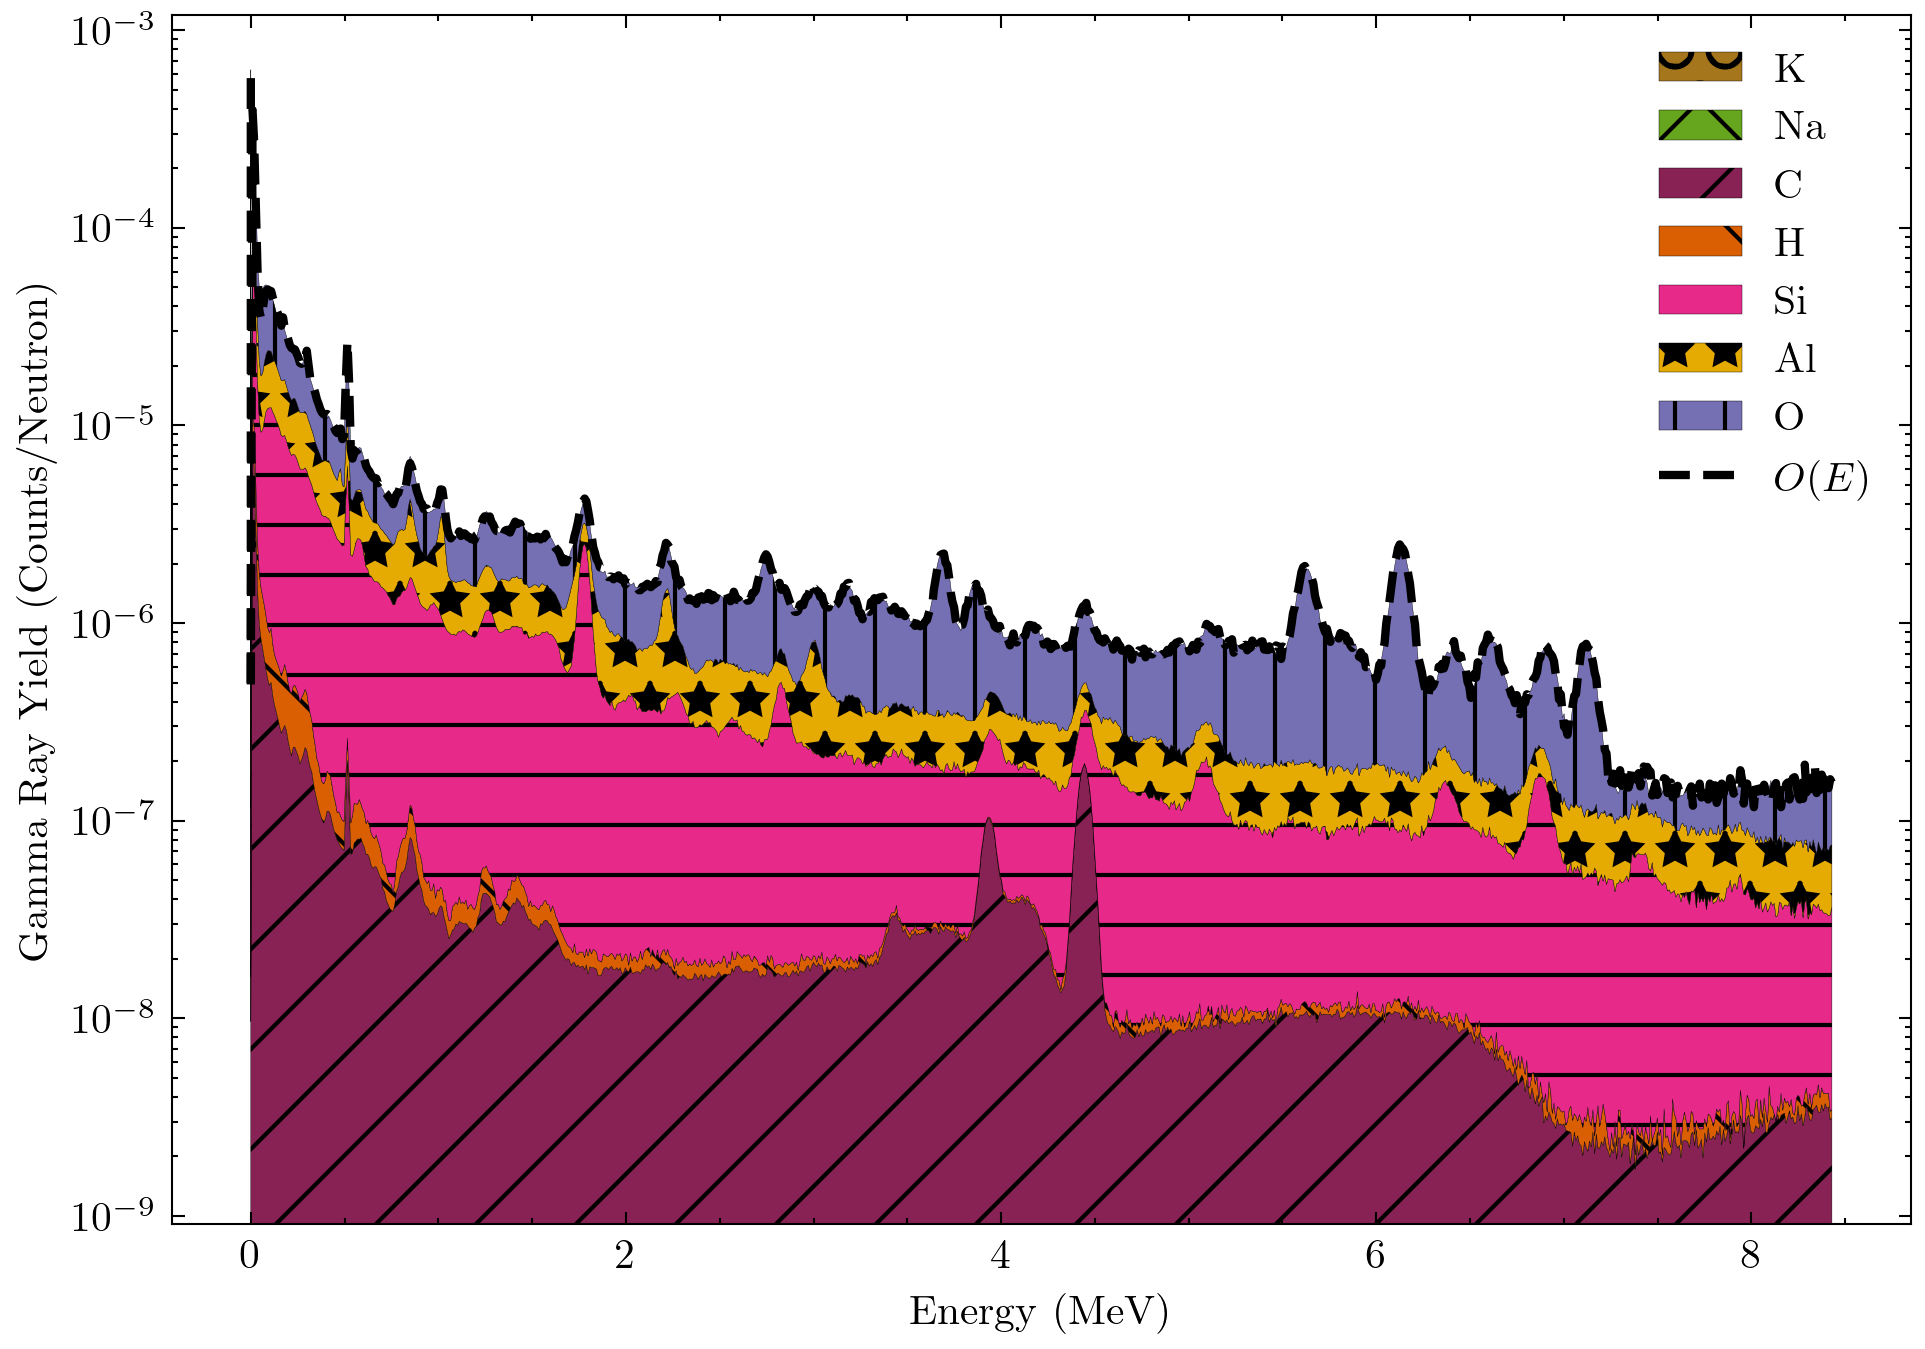

In [111]:
plt.figure(figsize=[double_col_width, double_col_width*.7])
# for spectrum in weighted_spectrums:
#     plt.plot(bins, spectrum)
# make a stackplot instead
plt.stackplot(
    bins, 
    weighted_spectrums[order], 
    labels=np.array(elem_names)[order], 
    # colors=plt.cm.tab10.colors,
    # hatch=hatches[0:len(elem_names)],
    colors=[element_colors.get(elem, '#333333') for elem in np.array(elem_names)[order]],
    hatch=[element_hatches.get(elem, '/') for elem in np.array(elem_names)[order]],
    linewidth=1e-1,
    linestyle='solid',
    edgecolor='black'
    )

plt.plot(bins, detector_readings[target], label='$O(E)$', color='black', linewidth=2, linestyle='--')

plt.xlabel('Energy (MeV)')
plt.ylabel('Gamma Ray Yield (Counts/Neutron)')
# plt.title('Linear Combination of Feldspar Spectra\nfound by component fitting (Elemental)')
plt.legend(fontsize=10)
plt.yscale('log')

# plt.xlim(0, 8)
# plt.ylim(None, 1e-4)
# plt.xlim(1, 8)
# plt.ylim(None, .6e-5)
# plt.savefig(figure_folder+'elemental_linear_combination_feldspar_RMSE.png', bbox_inches='tight')
plt.savefig(figure_folder+'elemental_linear_combination_feldspar.png', bbox_inches='tight')
plt.show()